# Task 3: joint GNN-BERT fusion

Review the five-mode joint experiment and run three real validation captions and
normalized audio graphs through its saved encoders and fusion head. This notebook
does not retrain, tune thresholds, or repeat test inference. Run the commands in
`docs/task3/README.md` first. The raw-audio preprocessing stage is upstream of this
demonstration; the input graph cache and source captions must be available.

In [1]:
from pathlib import Path
import json, re, sys
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RUN = ROOT / 'results/task3/joint_run2'
from src.task3.joint import verify_joint
verification = verify_joint(RUN)
assert verification['evaluated_test'], 'Finish the predeclared suite evaluation first.'
config = json.loads((RUN / 'run_config.json').read_text())
selection = json.loads((RUN / 'selection.json').read_text())
display(verification)
print('Overall selection:', selection['selected_mode'])
print('Fusion selection:', selection['selected_fusion'])

C:\Users\Roman\OneDrive\Documents\Neural_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'valid': True,
 'runs_checked': 5,
 'evaluated_test': True,
 'validation_only_selection': True,
 'encoder_updates_recorded': True,
 'frozen_layers_unchanged': True,
 'dataset_verified': True}

Overall selection: bert
Fusion selection: gated


## Matched ablation comparison

DistilBERT-only, GraphSAGE-only, concatenation, gating and graph-query-to-text-token
cross-attention share paired IDs, labels and splits. Attention masks exclude text
padding. The final transformer block, GraphSAGE and fusion/head update jointly
where present; lower transformer weights remain frozen. Every mode starts from
the original Task 1/2 encoders and its corresponding frozen seed-42 head. This
is continued fine-tuning with one seed; it is separate from the earlier three-seed
frozen-head comparison. Validation alone selects epochs, thresholds and modes.

,mode,best_epoch,threshold,validation_macro_f1,test_macro_f1,test_micro_f1,test_mean_average_precision,test_mean_pr_auc_trapezoidal
0,bert,3,0.20,0.460235,0.372654,0.673904,0.392178,0.375124
1,gnn,2,0.10,0.286124,0.269953,0.539846,0.270573,0.256215
2,concat,3,0.25,0.432575,0.387710,0.681010,0.405566,0.388396
3,gated,1,0.15,0.449573,0.407306,0.656314,0.414836,0.398611
4,cross_attention,1,0.20,0.410413,0.386686,0.650259,0.394350,0.377674


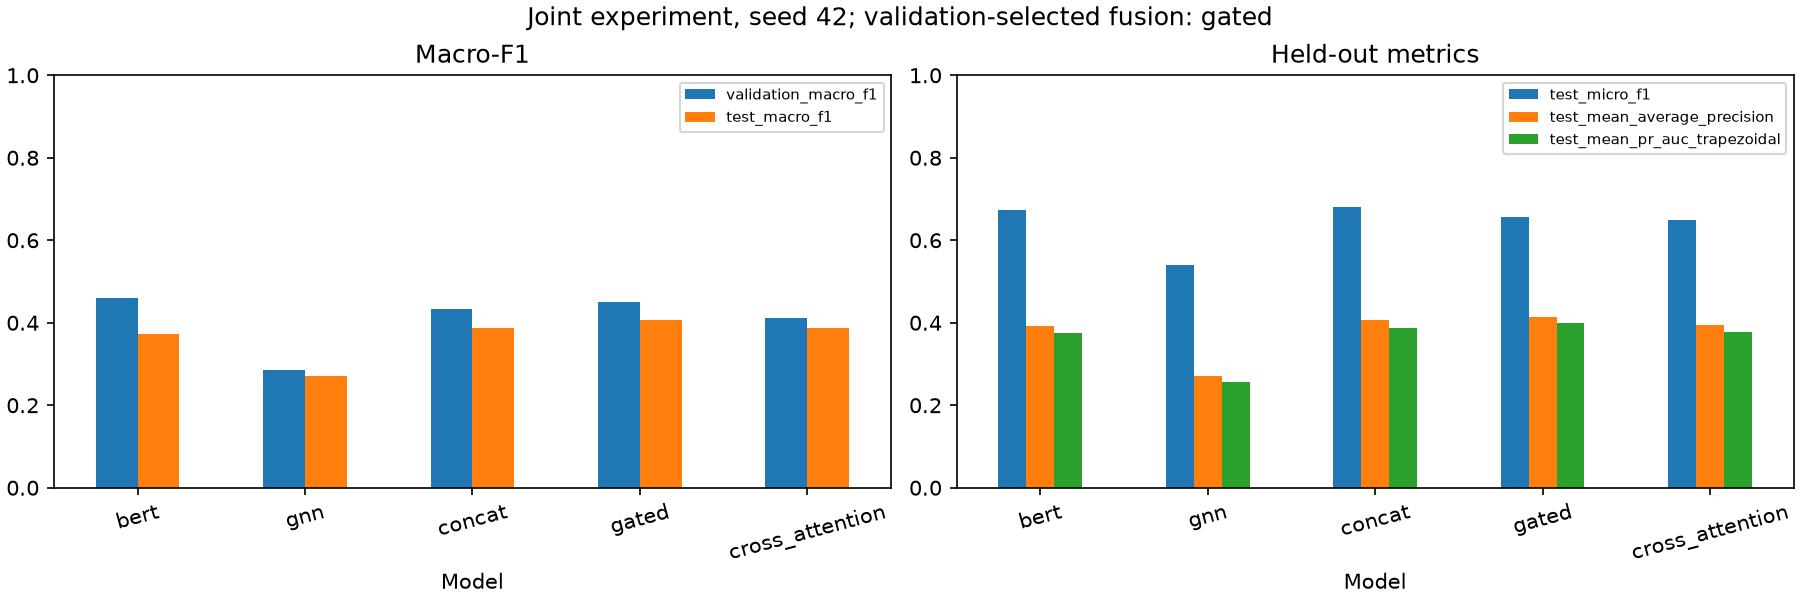

### bert

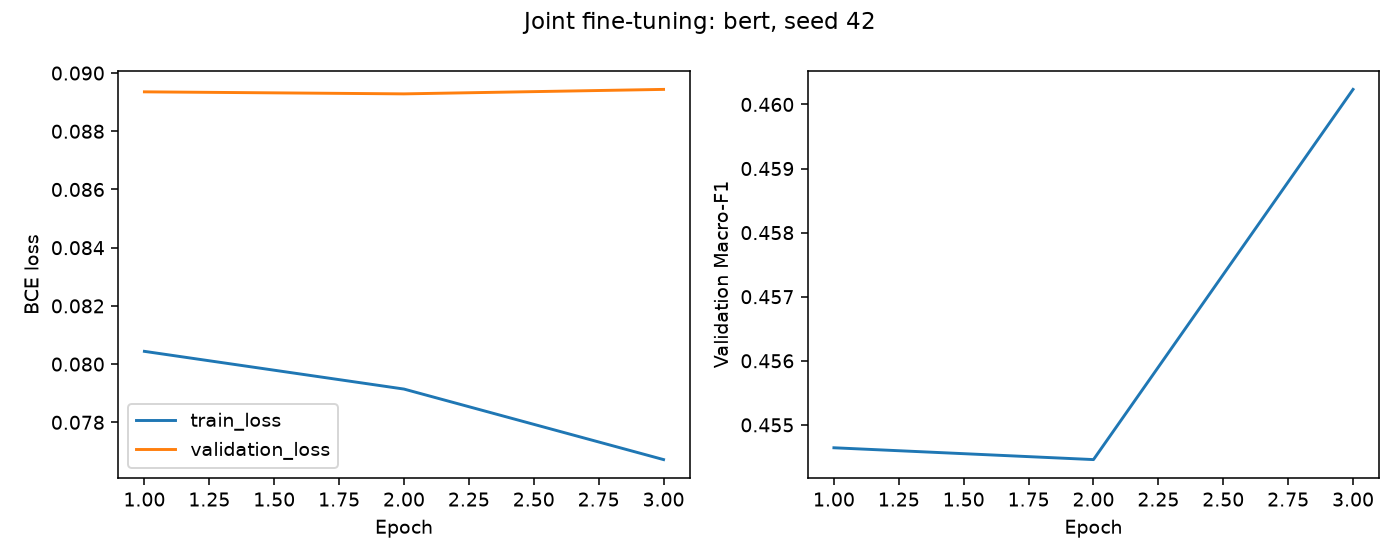

,parameter,max_abs_change
text,text_encoder.transformer.layer.5.attention.q_l...,0.001977
head,head.text_projection.weight,0.010979


### gnn

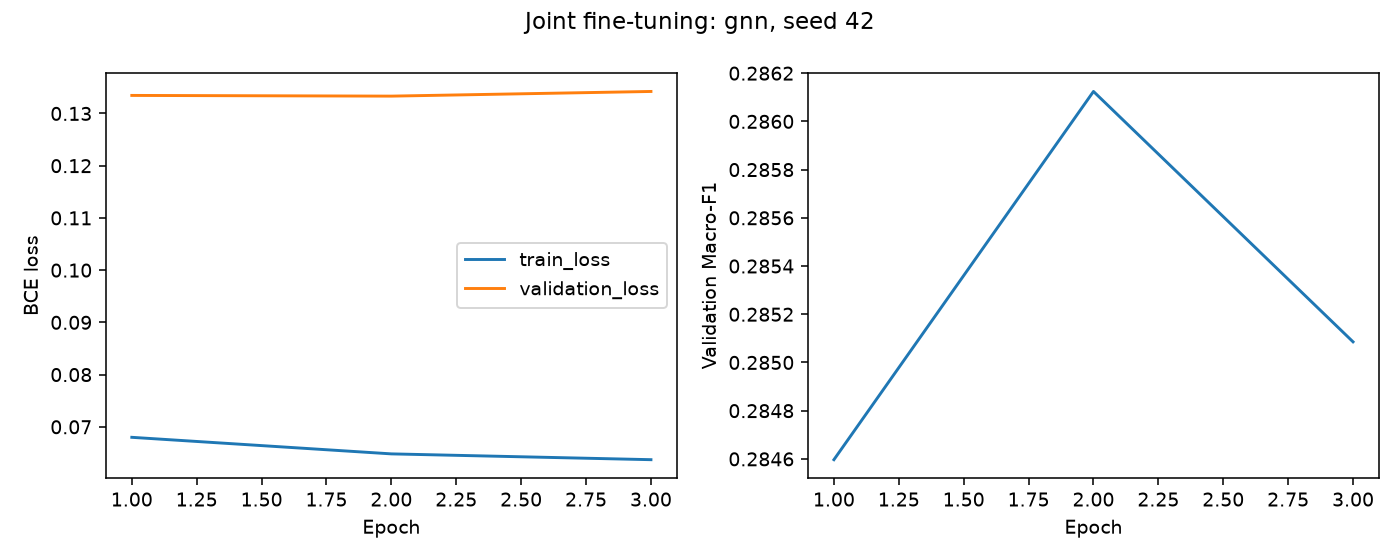

,parameter,max_abs_change
graph,graph_encoder.convs.0.lin_l.weight,0.01073
head,head.graph_projection.weight,0.009551


### concat

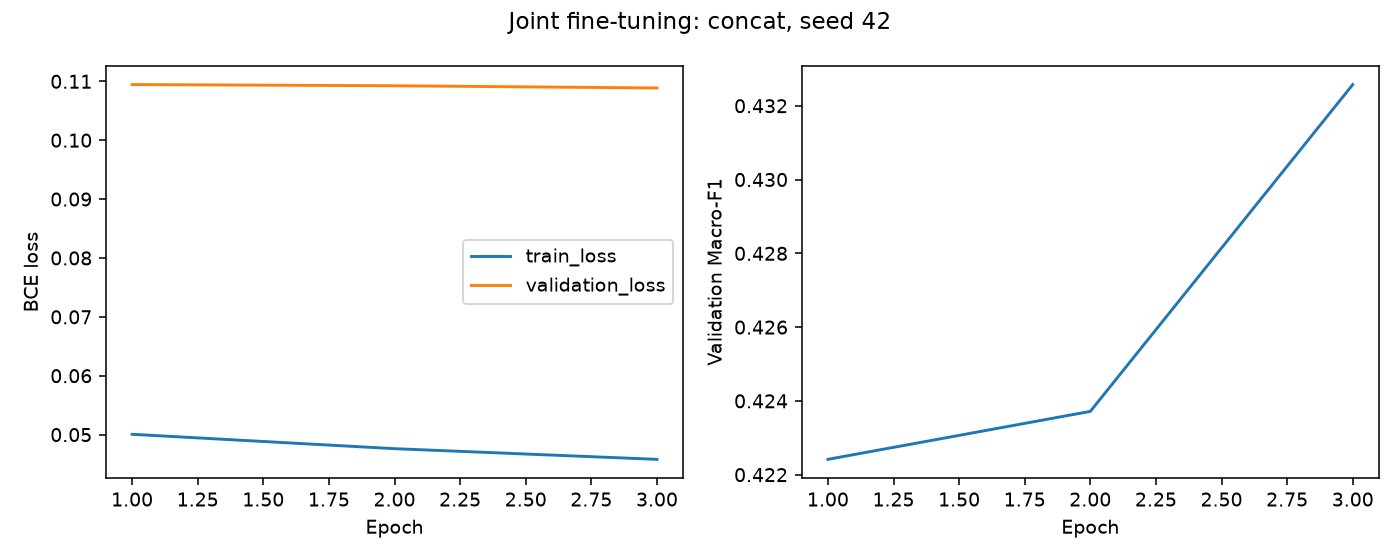

,parameter,max_abs_change
text,text_encoder.transformer.layer.5.attention.q_l...,0.00184
graph,graph_encoder.convs.0.lin_l.weight,0.014326
head,head.text_projection.weight,0.010706


### gated

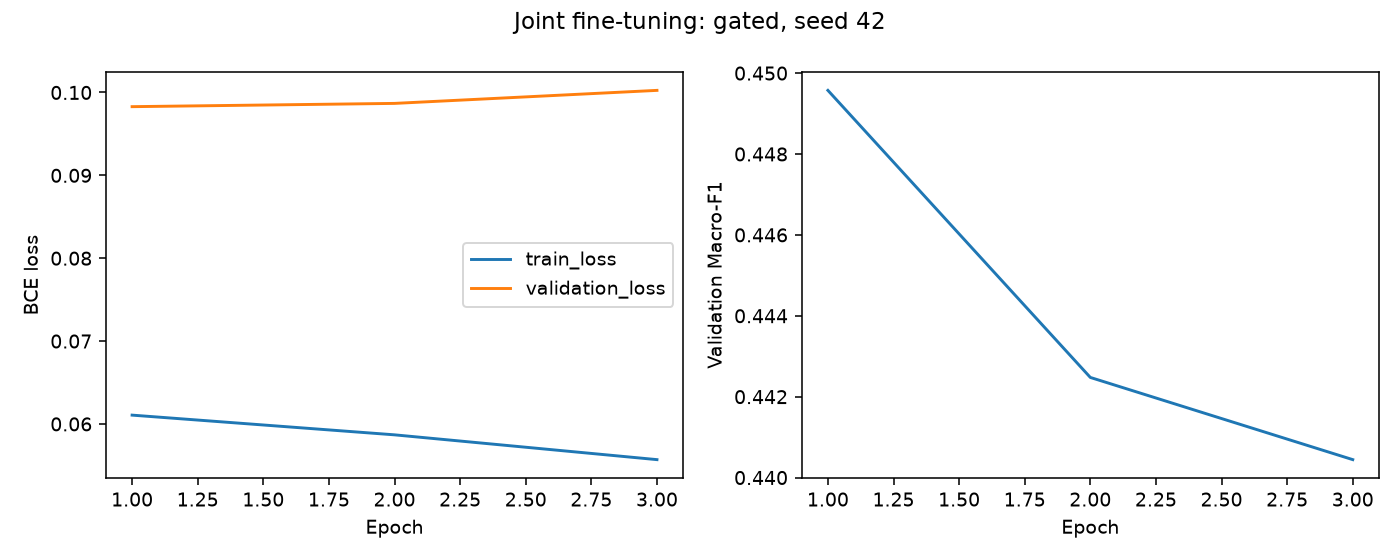

,parameter,max_abs_change
text,text_encoder.transformer.layer.5.attention.q_l...,0.001011
graph,graph_encoder.convs.0.lin_l.weight,0.007467
head,head.text_projection.weight,0.00623


### cross_attention

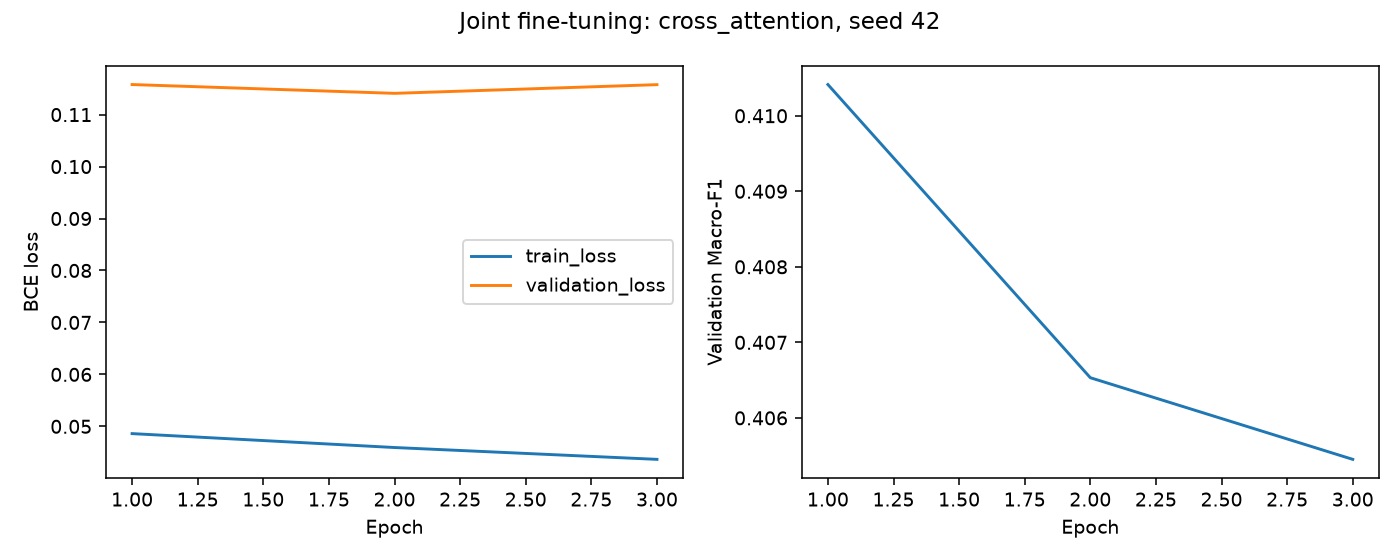

,parameter,max_abs_change
text,text_encoder.transformer.layer.5.attention.q_l...,0.000861
graph,graph_encoder.convs.0.lin_l.weight,0.007559
head,head.text_projection.weight,0.007138


In [2]:
columns = ['mode', 'best_epoch', 'threshold', 'validation_macro_f1', 'test_macro_f1',
           'test_micro_f1', 'test_mean_average_precision', 'test_mean_pr_auc_trapezoidal']
display(pd.read_csv(RUN / 'comparison.csv')[columns])
display(Image(filename=str(RUN / 'analysis/ablation.png')))
for mode in config['modes']:
    display(Markdown(f'### {mode}'))
    display(Image(filename=str(RUN / mode / 'training_curves.png')))
    proof = json.loads((RUN / mode / 'training_proof.json').read_text())
    display(pd.DataFrame(proof['selected_checkpoint_changes']).T)
    assert proof['frozen_text_sha256_before'] == proof['frozen_text_sha256_after']

## Genre and mood embeddings

The same validation t-SNE coordinates are colored using true positive AudioSet
annotations. Overlapping genres are explicit and also appear in individual
panels. Missing annotations are not confirmed negatives. Only Angry music is
available as a selected mood label, so broad mood discrimination is not shown.
Neither t-SNE nor attention weights establish causal explanations.

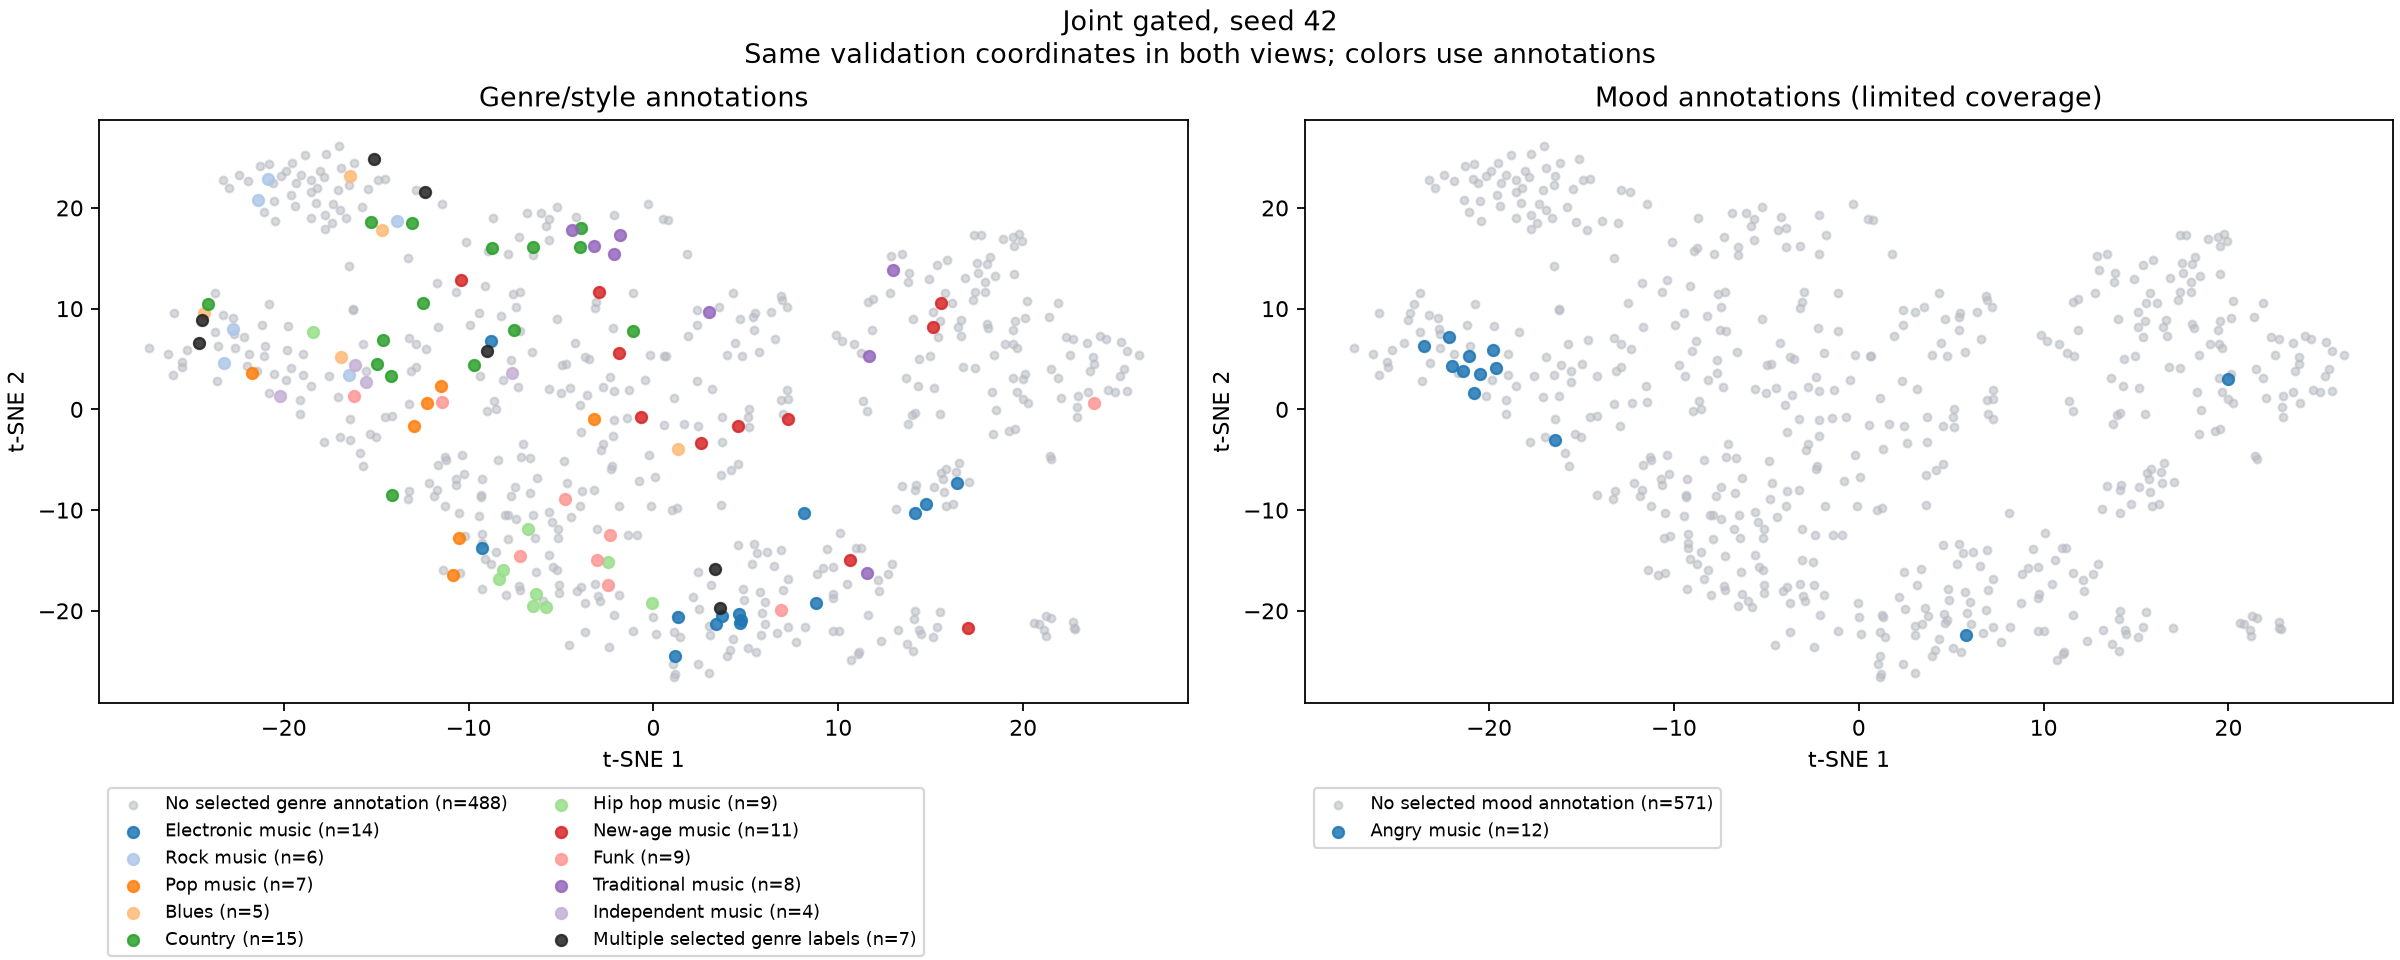

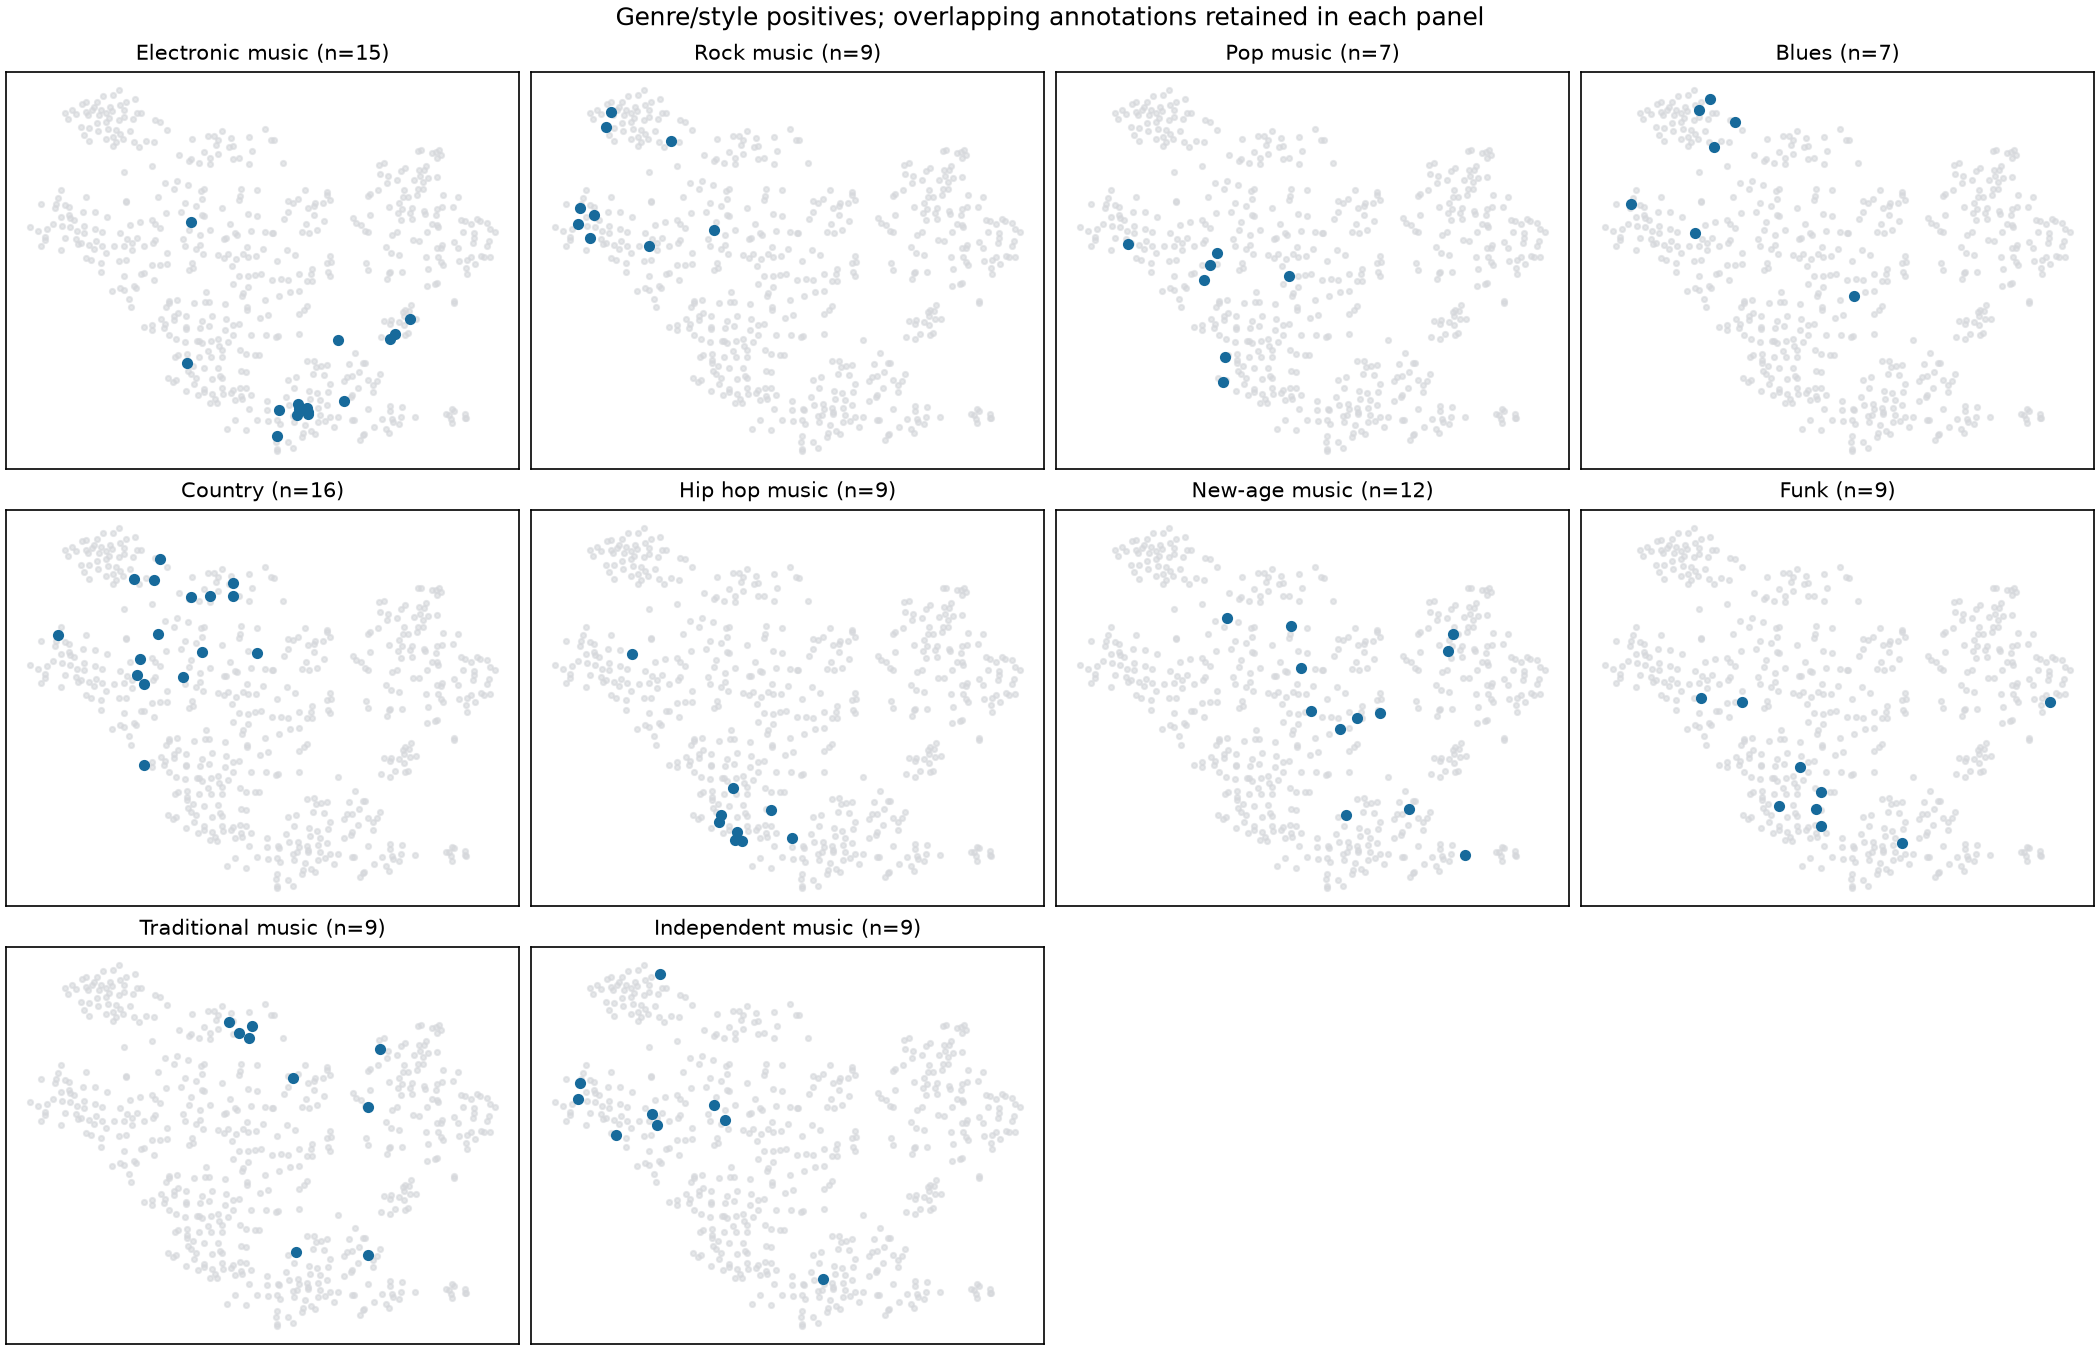

{'genre': {'annotated_samples': 95,
  'unannotated_samples': 488,
  'overlapping_samples': 7,
  'per_label_positive_support': {'Electronic music': 15,
   'Rock music': 9,
   'Pop music': 7,
   'Blues': 7,
   'Country': 16,
   'Hip hop music': 9,
   'New-age music': 12,
   'Funk': 9,
   'Traditional music': 9,
   'Independent music': 9}},
 'mood': {'annotated_samples': 12,
  'unannotated_samples': 571,
  'overlapping_samples': 0,
  'per_label_positive_support': {'Angry music': 12}}}

In [3]:
display(Image(filename=str(RUN / 'semantic_plots/genre_mood_tsne.png')))
display(Image(filename=str(RUN / 'semantic_plots/genre_label_panels.png')))
semantic = json.loads((RUN / 'semantic_plots/metadata.json').read_text())
display({group: semantic[group] for group in ['genre', 'mood']})

## Three fixed validation cases and failure analysis

Cases are the first three validation IDs in processed-manifest order, selected
independently of outcomes. The analysis contrasts the selected fusion with both
unimodal controls. Validation cases are diagnostic; held-out aggregate scores
estimate generalization. Incomplete labels can produce apparent false positives.

In [4]:
display(Markdown((RUN / 'analysis/cases.md').read_text(encoding='utf-8')))
analysis_text = (RUN / 'analysis/README.md').read_text(encoding='utf-8')
display(Markdown(re.sub(r'!\[[^\]]*\]\([^)]*\)', '', analysis_text)))

# Three fixed validation cases

The first three validation IDs in processed-manifest order are fixed independently of predictions. Thresholds and the fusion mode were selected on validation. These are in-sample validation diagnostics, not independent estimates of generalization. False positives mean missing positive annotations, which may reflect incomplete labels. No attention weights are used as causal explanations.

## Case 1: -5xOcMJpTUk_70_80

A male guitarist plays the guitar and speaks about technique in this online video tutorial. The male voice is strong and commanding, along with guitar string twang sounds, clearly demonstrating the technique. The audio quality is mediocre.

Annotated labels: Music, Musical instrument, Guitar, Plucked string instrument, Speech, Acoustic guitar.

**bert** (threshold 0.20): true positive: Music, Musical instrument, Guitar, Plucked string instrument, Speech, Acoustic guitar; false positive: none; false negative: none.

**gnn** (threshold 0.10): true positive: Music, Musical instrument, Guitar, Plucked string instrument, Speech, Acoustic guitar; false positive: Effects unit, Electric guitar, Distortion; false negative: none.

**gated** (threshold 0.15): true positive: Music, Musical instrument, Guitar, Plucked string instrument, Speech, Acoustic guitar; false positive: none; false negative: none.

Selected-fusion top probabilities:

| name | probability | target | predicted | status |
| --- | --- | --- | --- | --- |
| Music | 0.9949 | 1 | 1 | true_positive |
| Plucked string instrument | 0.9896 | 1 | 1 | true_positive |
| Guitar | 0.9742 | 1 | 1 | true_positive |
| Musical instrument | 0.9646 | 1 | 1 | true_positive |
| Acoustic guitar | 0.5769 | 1 | 1 | true_positive |
| Speech | 0.5616 | 1 | 1 | true_positive |
| Electric guitar | 0.1430 | 0 | 0 | true_negative |
| Distortion | 0.1249 | 0 | 0 | true_negative |

## Case 2: -8C-gydUbR8_30_40

A children’s choir sings this devotional melody. The song is medium tempo with a steady bass line, drumming rhythm and clapping percussion. The song is black gospel choral music played in front of a live congregation. The audio quality is very poor.

Annotated labels: Music.

**bert** (threshold 0.20): true positive: Music; false positive: none; false negative: none.

**gnn** (threshold 0.10): true positive: Music; false positive: none; false negative: none.

**gated** (threshold 0.15): true positive: Music; false positive: none; false negative: none.

Selected-fusion top probabilities:

| name | probability | target | predicted | status |
| --- | --- | --- | --- | --- |
| Music | 0.9797 | 1 | 1 | true_positive |
| Singing | 0.0422 | 0 | 0 | true_negative |
| Speech | 0.0222 | 0 | 0 | true_negative |
| Musical instrument | 0.0176 | 0 | 0 | true_negative |
| Pop music | 0.0057 | 0 | 0 | true_negative |
| Music of Africa | 0.0051 | 0 | 0 | true_negative |
| Rock music | 0.0050 | 0 | 0 | true_negative |
| Song | 0.0047 | 0 | 0 | true_negative |

## Case 3: -Bu7YaslRW0_30_40

A synth pad is playing a drone sound in the lower mid range. Cymbals are creating atmosphere while a flute/string/brass sound is playing a melody. The whole recording is full of reverb. This song may be playing in a forest documentary.

Annotated labels: Music.

**bert** (threshold 0.20): true positive: Music; false positive: none; false negative: none.

**gnn** (threshold 0.10): true positive: Music; false positive: New-age music; false negative: none.

**gated** (threshold 0.15): true positive: Music; false positive: New-age music; false negative: none.

Selected-fusion top probabilities:

| name | probability | target | predicted | status |
| --- | --- | --- | --- | --- |
| Music | 0.9919 | 1 | 1 | true_positive |
| New-age music | 0.2400 | 0 | 1 | false_positive |
| Traditional music | 0.0708 | 0 | 0 | true_negative |
| Musical instrument | 0.0321 | 0 | 0 | true_negative |
| Electronic music | 0.0165 | 0 | 0 | true_negative |
| Effects unit | 0.0125 | 0 | 0 | true_negative |
| Independent music | 0.0102 | 0 | 0 | true_negative |
| Angry music | 0.0084 | 0 | 0 | true_negative |


# Task 3 joint-fusion results

Completed five-mode joint fine-tuning experiment, seed 42. Validation selects **bert** overall and **gated** among fusion models.

## Protocol

Configured maximum 3 epochs; patience 2; batch size 8; projection width 64. Initial heads: Saved per-mode frozen heads. The final 1 transformer block(s), GraphSAGE and active head train using live encoder forwards. Lower text layers remain frozen. Checkpoints record active encoder/head updates and unchanged frozen weights.

All modes share paired IDs, label order and splits. Validation alone selects epochs, thresholds and mode. All predeclared modes are then evaluated on held-out test clips. This is one joint-training seed; the earlier three-seed frozen experiment is separate. Historical encoder pretraining cohorts differ, as documented in the run guide.

## Ablation matrix

| mode | best_epoch | threshold | validation_macro_f1 | test_macro_f1 | test_micro_f1 | test_mean_average_precision | test_mean_pr_auc_trapezoidal |
| --- | --- | --- | --- | --- | --- | --- | --- |
| bert | 3 | 0.2000 | 0.4602 | 0.3727 | 0.6739 | 0.3922 | 0.3751 |
| gnn | 2 | 0.1000 | 0.2861 | 0.2700 | 0.5398 | 0.2706 | 0.2562 |
| concat | 3 | 0.2500 | 0.4326 | 0.3877 | 0.6810 | 0.4056 | 0.3884 |
| gated | 1 | 0.1500 | 0.4496 | 0.4073 | 0.6563 | 0.4148 | 0.3986 |
| cross_attention | 1 | 0.2000 | 0.4104 | 0.3867 | 0.6503 | 0.3943 | 0.3777 |

mAP is mean per-label average precision. Trapezoidal mean PR-AUC is a separate metric. Both average only labels with positive evaluation support.



## Failure analysis

Selected gated versus bert: test Macro-F1 difference +0.0347; per-example F1 improves for 124 clips, worsens for 159, and ties for 323. These descriptive counts use each model's saved threshold and are not significance tests.

Selected gated versus gnn: test Macro-F1 difference +0.1374; per-example F1 improves for 286 clips, worsens for 85, and ties for 235. These descriptive counts use each model's saved threshold and are not significance tests.

Lowest selected-fusion per-label test F1 (ties ordered by support and label ID):

| name | support | f1 | average_precision | false_positives | false_negatives |
| --- | --- | --- | --- | --- | --- |
| Pop music | 7 | 0.0000 | 0.0267 | 8 | 7 |
| Song | 13 | 0.1143 | 0.1522 | 20 | 11 |
| Funk | 11 | 0.1429 | 0.2208 | 2 | 10 |
| Bowed string instrument | 8 | 0.1600 | 0.3373 | 15 | 6 |
| Independent music | 12 | 0.1905 | 0.2092 | 7 | 10 |
| Electronic music | 23 | 0.2449 | 0.2040 | 20 | 17 |
| Traditional music | 8 | 0.2727 | 0.2632 | 11 | 5 |
| Blues | 9 | 0.2857 | 0.2612 | 9 | 6 |

Low-support labels have unstable estimates. Incomplete AudioSet positives can make sensible predictions count as false positives. Captions often directly describe instruments, while ten audio graph segments compress temporal detail; these are plausible limitations, not established causal explanations of an individual error. Missing-audio selection and the absence of artist-disjoint splits limit generalization. A negative fusion result is reported without selecting a replacement using test scores.

[Three fixed validation cases](cases.md) include captions, annotations, predicted labels, errors and probabilities. They describe observed model behavior; attention weights do not establish causal importance.

## Remaining scope qualifications

MusicCaps is a substitute for the assignment's named datasets; instructor acceptance remains undocumented. Genre/mood t-SNE uses explicit positive AudioSet annotations, retains genre overlap and displays missing annotations. Only Angry music is available as a selected mood label, so broad mood coverage cannot be claimed.

The run's per-mode training_curves.png files contain measured BCE and validation Macro-F1 curves. The semantic_plots directory is generated separately using the saved validation-selected fusion embeddings.


## Live encoder inference from the joint checkpoint

Restore the validation-selected fusion model, tokenize the real captions, and
forward normalized audio node features and edges through GraphSAGE and caption
tokens through DistilBERT. No cached encoder embeddings are used here. The saved
threshold and ordered label vocabulary are retained. These three validation
predictions are checked against the saved prediction artifact.

In [5]:
import torch
from torch.utils.data import Subset
from transformers import AutoTokenizer
from src.task3.joint import restore_model, PairedDataset, predict
torch.set_num_threads(6)
mode = selection['selected_fusion']
saved = torch.load(RUN / mode / 'best_model.pt', map_location='cpu', weights_only=True, mmap=True)
model = restore_model(saved, 'cpu')
tokenizer = AutoTokenizer.from_pretrained(RUN / 'tokenizer', local_files_only=True)
source = json.loads(Path(config['source_manifest']).read_text(encoding='utf-8'))
validation = PairedDataset(config['processed_manifest'], source, 'validation',
                           config['graph_variant'], tokenizer, config['max_length'])
prediction = predict(model, Subset(validation, [0, 1, 2]), 3, 'cpu')
with np.load(RUN / mode / 'validation_predictions.npz') as expected:
    np.testing.assert_array_equal(prediction['sample_ids'], expected['sample_ids'][:3])
    np.testing.assert_array_equal(prediction['targets'], expected['targets'][:3])
    np.testing.assert_allclose(prediction['probabilities'], expected['probabilities'][:3], atol=1e-5, rtol=1e-5)
names = json.loads((ROOT / 'src/task1/audioset_names.json').read_text(encoding='utf-8'))
rows = []
for i, identifier in enumerate(prediction['sample_ids']):
    record = validation.records[i]
    predicted = [names.get(label, label) for label, p in zip(saved['label_names'], prediction['probabilities'][i]) if p >= saved['threshold']]
    annotated = [names.get(label, label) for label, y in zip(saved['label_names'], prediction['targets'][i]) if y]
    rows.append(dict(sample_id=identifier, caption=record['text'], predicted=', '.join(predicted), annotated=', '.join(annotated)))
display(pd.DataFrame(rows))
print('Three live encoder predictions match saved validation predictions; threshold:', saved['threshold'])

,sample_id,caption,predicted,annotated
0,-5xOcMJpTUk_70_80,A male guitarist plays the guitar and speaks a...,"Music, Musical instrument, Guitar, Plucked str...","Music, Musical instrument, Guitar, Plucked str..."
1,-8C-gydUbR8_30_40,A children’s choir sings this devotional melod...,Music,Music
2,-Bu7YaslRW0_30_40,A synth pad is playing a drone sound in the lo...,"Music, New-age music",Music


Three live encoder predictions match saved validation predictions; threshold: 0.15


## Scope

MusicCaps substitutes for the assignment's named datasets; instructor acceptance
remains undocumented. The text encoder's earlier training included 1,089 extra
training-only captions. Graphs compress the audio into ten segments. Missing
audio and incomplete labels affect this cohort, and artist-disjoint generalization
has not been established. No statistical significance is claimed from one joint
seed. See the submission audit for final report and packaging requirements.